# **Classification of Phishing Websites Using Machine Learning and URL Analytics**

# **Section 1: Importing Files**
In this section, We imported relevent Library files and we also loaded the dataset in zip format

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.io import arff
import zipfile

# Extract and Load Data
with zipfile.ZipFile('phishing+websites.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

data, meta = arff.loadarff('Training Dataset.arff')
df = pd.DataFrame(data)

# Clean byte strings to integers
for col in df.columns:
    if df[col].dtype == object:
        df[col] = df[col].str.decode('utf-8').astype(int)

# **Section 2:Exploratory Data Analysis**


## **Checking for Missing Values in Dataset**

In [ ]:
# 1. Missing Values Calculation
print("Missing Values Summary:")
print(df.isnull().sum().sum())

Missing Values Summary:
0


## **Pair Plot for Features**

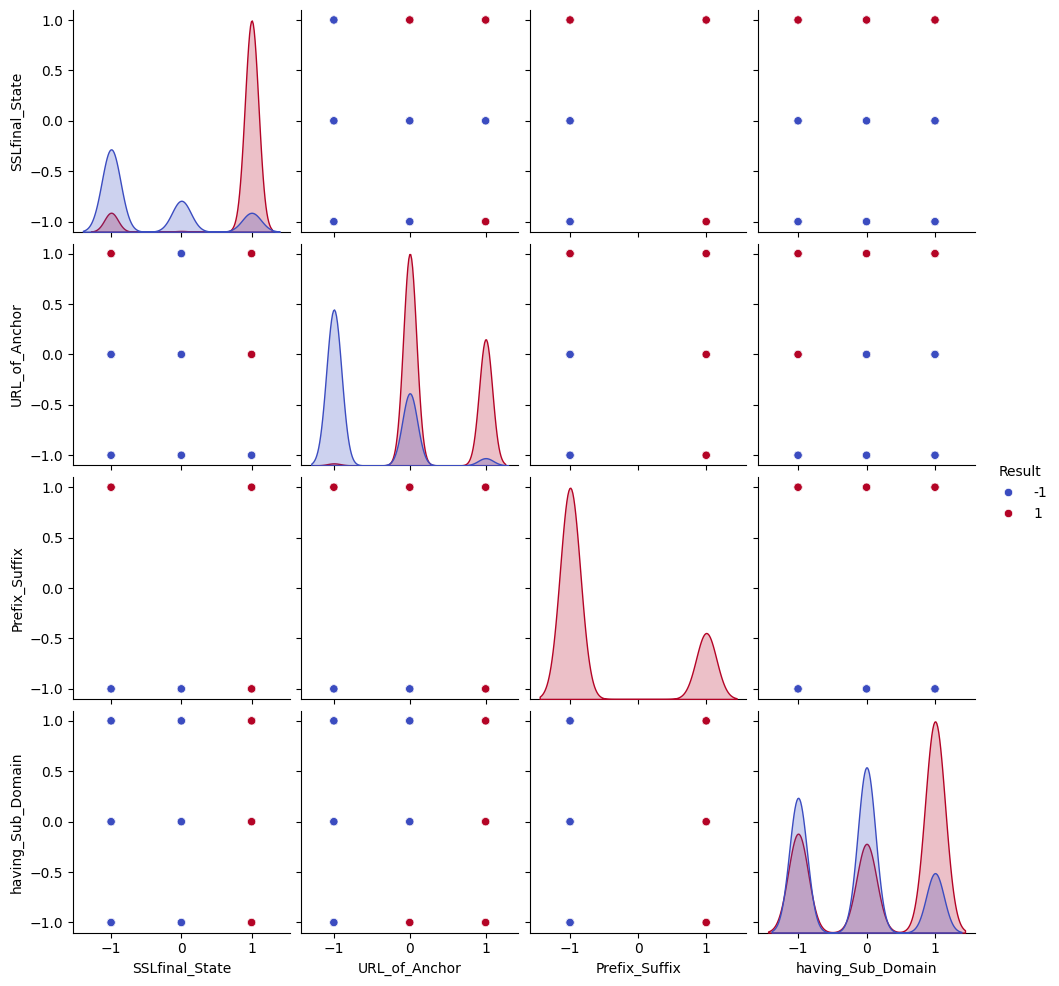

In [ ]:
# 2. Pair Plot of Selected Critical Features
# Selecting features commonly identified as high-impact
selected_features = ['SSLfinal_State', 'URL_of_Anchor', 'Prefix_Suffix', 'having_Sub_Domain', 'Result']
sns.pairplot(df[selected_features], hue='Result', palette='coolwarm')
plt.savefig('pair_plot.png')

## **Correlational Heatmap for impactful features**

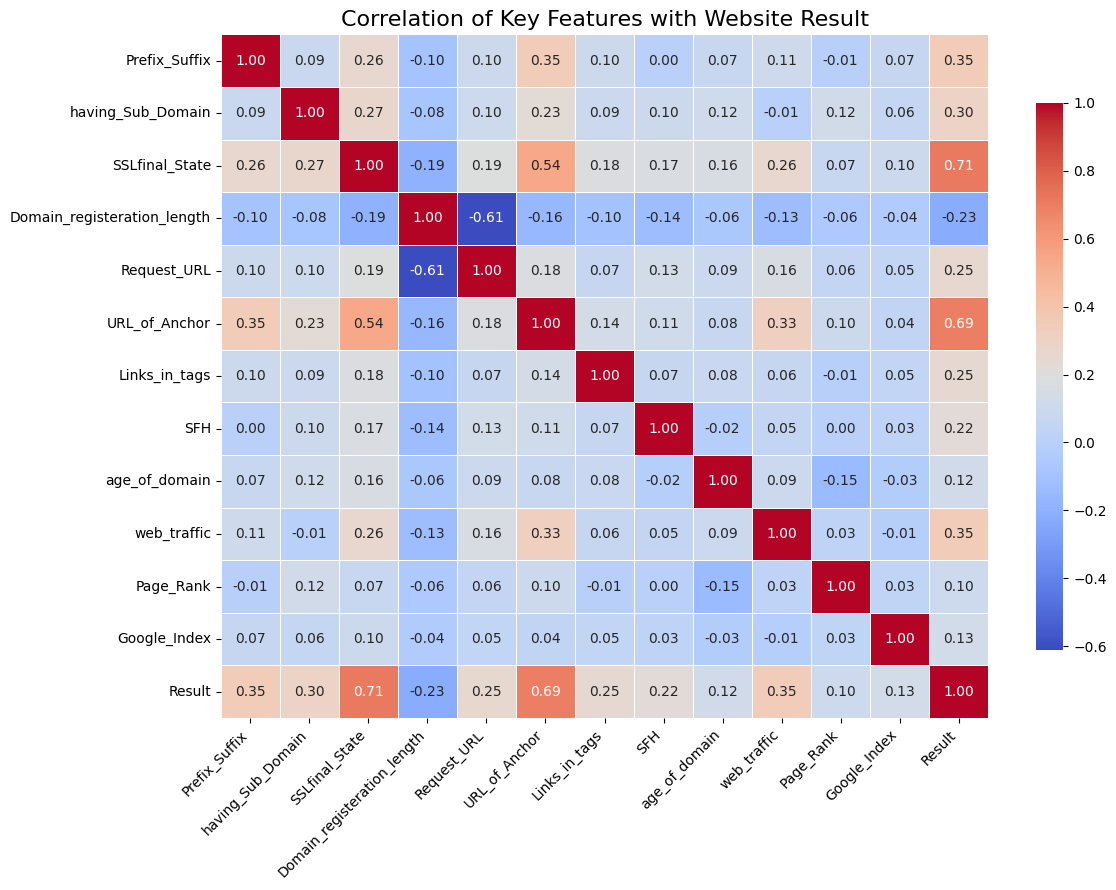

In [ ]:
#1. Calculate the correlation matrix
corr_matrix = df.corr()

# 2. Identify features with a correlation > 0.1 or < -0.1 with the 'Result'
# We focus on the most impactful predictors to keep the map readable
top_corr_features = corr_matrix.index[abs(corr_matrix["Result"]) > 0.1]

# 3. Create the readable heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df[top_corr_features].corr(),
            annot=True,          # Show the correlation numbers
            fmt=".2f",           # Format to 2 decimal places
            cmap='coolwarm',     # Better contrast for positive/negative values
            linewidths=0.5,      # Add lines between squares for clarity
            cbar_kws={"shrink": .8})

plt.title('Correlation of Key Features with Website Result', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## **Distribution of Target Variable**

/tmp/ipython-input-3155589233.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Result', data=df, palette='viridis')


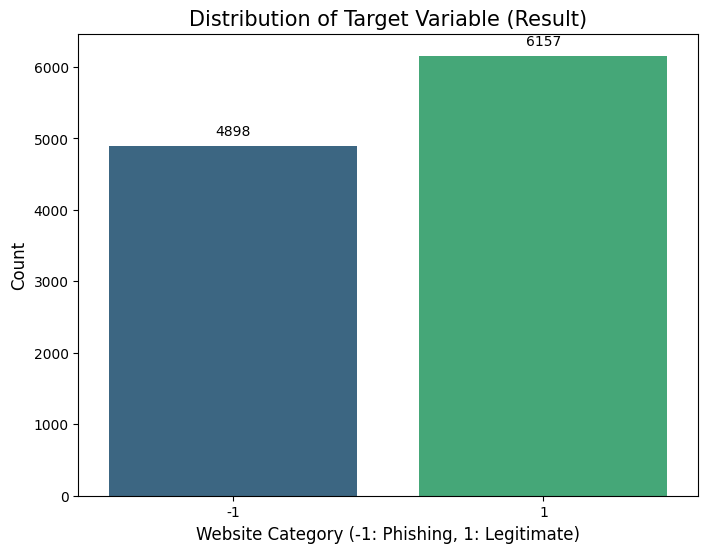

Target Variable Counts:
Result
 1    6157
-1    4898
Name: count, dtype: int64


In [ ]:
# Plotting the target variable distribution
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Result', data=df, palette='viridis')

# Adding labels and titles
plt.title('Distribution of Target Variable (Result)', fontsize=15)
plt.xlabel('Website Category (-1: Phishing, 1: Legitimate)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Adding count annotations on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10), textcoords='offset points')

plt.show()

# Print exact counts
print("Target Variable Counts:")
print(df['Result'].value_counts())

## **Correlation of Features with Legitimate vs Phishing Status**

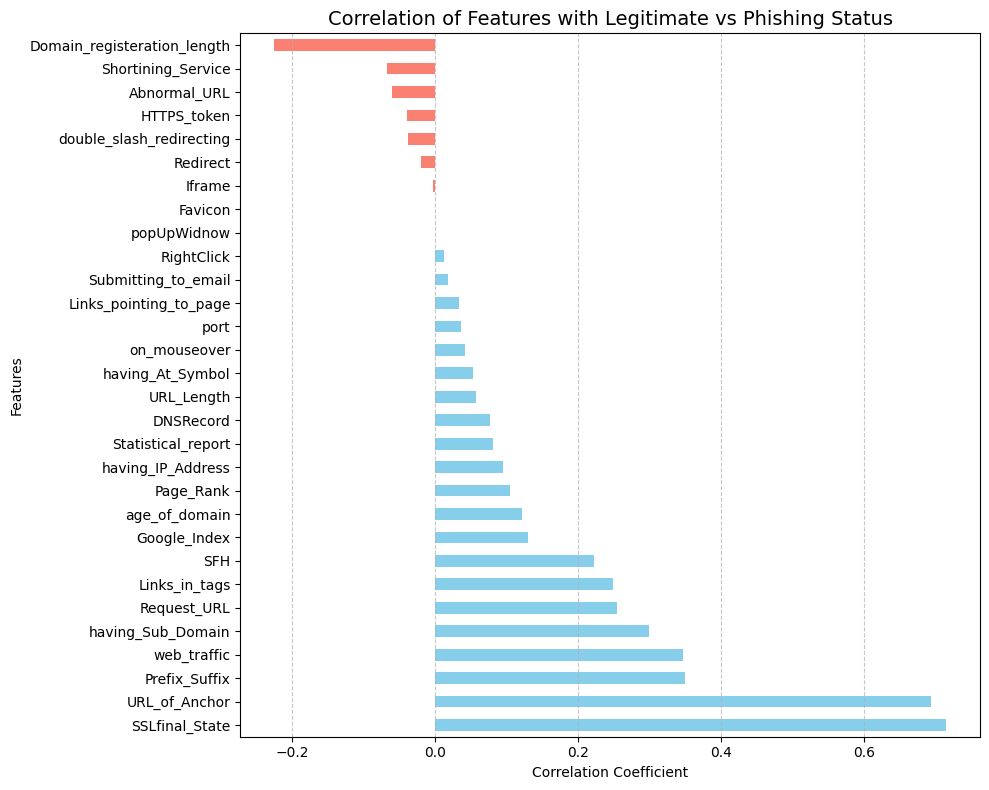

In [ ]:
# Calculate correlation specifically with the target 'Result'
target_corr = df.corr()['Result'].sort_values(ascending=False).drop('Result')

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color=(target_corr > 0).map({True: 'skyblue', False: 'salmon'}))

plt.title('Correlation of Features with Legitimate vs Phishing Status', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# **Section 3: Training & Evaluating Models**


Model: Random Forest
              precision    recall  f1-score   support

    Phishing       0.97      0.95      0.96       956
  Legitimate       0.96      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Model: Gradient Boosting
              precision    recall  f1-score   support

    Phishing       0.95      0.93      0.94       956
  Legitimate       0.95      0.96      0.96      1255

    accuracy                           0.95      2211
   macro avg       0.95      0.95      0.95      2211
weighted avg       0.95      0.95      0.95      2211


Model: Logistic Regression
              precision    recall  f1-score   support

    Phishing       0.92      0.90      0.91       956
  Legitimate       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.92      0.92      221

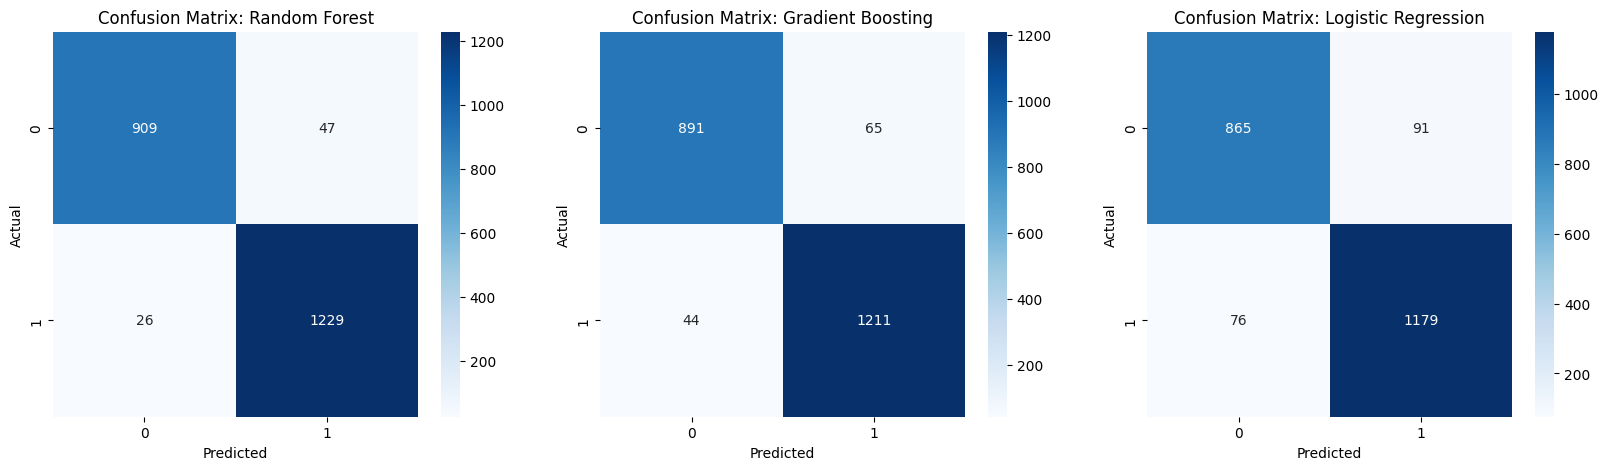

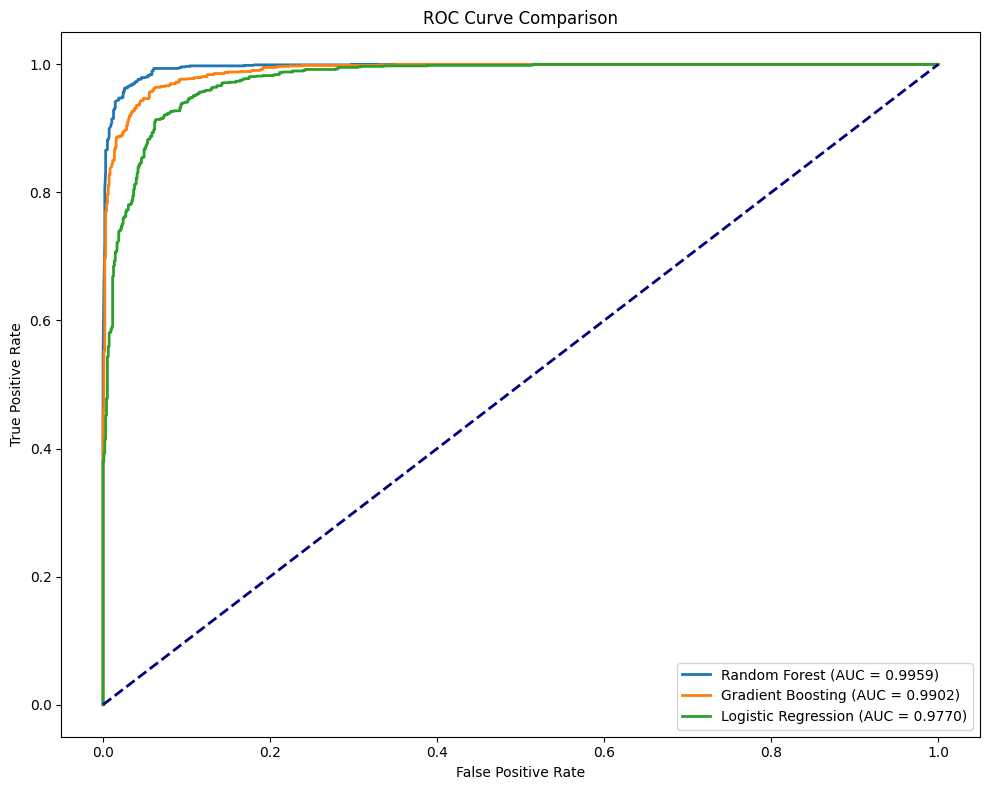


--- Summarized Results Table ---
              Model  Accuracy  Precision   Recall  F1-Score  FPR (False Positive Rate)      AUC
      Random Forest  0.966983   0.963166 0.979283  0.971158                   0.049163 0.995943
  Gradient Boosting  0.950701   0.949060 0.964940  0.956934                   0.067992 0.990248
Logistic Regression  0.924469   0.928346 0.939442  0.933861                   0.095188 0.977029


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, auc, precision_score, recall_score, f1_score)

# 1. Data Preparation
X = df.drop('Result', axis=1)
y = df['Result'].map({-1: 0, 1: 1}) # Mapping to 0 (Phishing) and 1 (Legitimate)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Model Initialization
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

# 3. Training and Evaluation Loop
summary_data = []
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(20, 5))
fig_roc, ax_roc = plt.subplots(figsize=(10, 8))

for i, (name, model) in enumerate(models.items()):
    # Fit and Predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Probability for ROC

    # A. Classification Report
    print(f"\n{'='*20}\nModel: {name}\n{'='*20}")
    print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legitimate']))

    # B. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_cm[i])
    axes_cm[i].set_title(f'Confusion Matrix: {name}')
    axes_cm[i].set_xlabel('Predicted')
    axes_cm[i].set_ylabel('Actual')

    # C. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

    # D. Summary Data
    tn, fp, fn, tp = cm.ravel()
    summary_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "FPR (False Positive Rate)": fp / (fp + tn),
        "AUC": roc_auc
    })

# Finalizing ROC Plot
ax_roc.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax_roc.set_title('ROC Curve Comparison')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(loc="lower right")

plt.tight_layout()
plt.show()

# 4. Summarized Result
summarized_results = pd.DataFrame(summary_data).sort_values(by="Accuracy", ascending=False)
print("\n--- Summarized Results Table ---")
print(summarized_results.to_string(index=False))

# **Section 4: Hyperparameter Optimizaion using Bayesian Optimization**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 24.5 MB/s eta 0:00:00


In [ ]:
import optuna
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 10, 40),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 5),
        'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy'])
    }
    model = RandomForestClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=3, n_jobs=-1).mean()

def gb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 8)
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=3, n_jobs=-1).mean()

def lr_objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10.0, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs'])
    }
    model = LogisticRegression(**params, max_iter=2000, random_state=42)
    return cross_val_score(model, X_train, y_train, cv=3, n_jobs=-1).mean()

# 3. Execution
study_results = {}
for name, obj in [("Random Forest", rf_objective), ("Gradient Boosting", gb_objective), ("Logistic Regression", lr_objective)]:
    print(f"Optimizing {name}...")
    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=15)
    study_results[name] = study

[I 2026-01-27 14:12:26,324] A new study created in memory with name: no-name-29685e3c-7595-4196-a3db-a6706cb955f5


Optimizing Random Forest...


[I 2026-01-27 14:12:37,273] Trial 0 finished with value: 0.9676616915422885 and parameters: {'n_estimators': 273, 'max_depth': 19, 'min_samples_split': 2, 'criterion': 'entropy'}. Best is trial 0 with value: 0.9676616915422885.
[I 2026-01-27 14:12:39,543] Trial 1 finished with value: 0.9659656264133876 and parameters: {'n_estimators': 147, 'max_depth': 33, 'min_samples_split': 4, 'criterion': 'gini'}. Best is trial 0 with value: 0.9676616915422885.
[I 2026-01-27 14:12:43,219] Trial 2 finished with value: 0.9678878335594754 and parameters: {'n_estimators': 206, 'max_depth': 39, 'min_samples_split': 3, 'criterion': 'gini'}. Best is trial 2 with value: 0.9678878335594754.
[I 2026-01-27 14:12:45,638] Trial 3 finished with value: 0.9659656264133876 and parameters: {'n_estimators': 198, 'max_depth': 29, 'min_samples_split': 4, 'criterion': 'gini'}. Best is trial 2 with value: 0.9678878335594754.
[I 2026-01-27 14:12:47,744] Trial 4 finished with value: 0.9681139755766622 and parameters: {'n_e

Optimizing Gradient Boosting...


[I 2026-01-27 14:13:18,104] Trial 0 finished with value: 0.9483265490728178 and parameters: {'n_estimators': 179, 'learning_rate': 0.011093442412042864, 'max_depth': 7}. Best is trial 0 with value: 0.9483265490728178.
[I 2026-01-27 14:13:26,765] Trial 1 finished with value: 0.9678878335594753 and parameters: {'n_estimators': 195, 'learning_rate': 0.1615406549947192, 'max_depth': 6}. Best is trial 1 with value: 0.9678878335594753.
[I 2026-01-27 14:13:37,653] Trial 2 finished with value: 0.9664179104477612 and parameters: {'n_estimators': 199, 'learning_rate': 0.19486827317580882, 'max_depth': 7}. Best is trial 1 with value: 0.9678878335594753.
[I 2026-01-27 14:13:48,932] Trial 3 finished with value: 0.9659656264133876 and parameters: {'n_estimators': 188, 'learning_rate': 0.02931422858310668, 'max_depth': 8}. Best is trial 1 with value: 0.9678878335594753.
[I 2026-01-27 14:13:56,589] Trial 4 finished with value: 0.9687924016282224 and parameters: {'n_estimators': 204, 'learning_rate': 0

Optimizing Logistic Regression...


[I 2026-01-27 14:14:54,314] Trial 1 finished with value: 0.9289914066033469 and parameters: {'C': 6.387008750978191, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.9293306196291272.
[I 2026-01-27 14:14:54,490] Trial 2 finished with value: 0.9285391225689733 and parameters: {'C': 0.835908034601203, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9293306196291272.
[I 2026-01-27 14:14:54,697] Trial 3 finished with value: 0.9292175486205337 and parameters: {'C': 8.270718988385571, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9293306196291272.
[I 2026-01-27 14:14:54,822] Trial 4 finished with value: 0.9292175486205337 and parameters: {'C': 3.898856566389633, 'solver': 'lbfgs'}. Best is trial 0 with value: 0.9293306196291272.
[I 2026-01-27 14:14:55,046] Trial 5 finished with value: 0.9292175486205337 and parameters: {'C': 9.23414831492214, 'solver': 'liblinear'}. Best is trial 0 with value: 0.9293306196291272.
[I 2026-01-27 14:14:55,164] Trial 6 finished with value: 0.92955

## **Training and Evaluating with Optimized Parameters**


Final Report: Random Forest
              precision    recall  f1-score   support

           0       0.97      0.96      0.96       956
           1       0.97      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Final Report: Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       956
           1       0.96      0.99      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211


Final Report: Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       956
           1       0.93      0.94      0.93      1255

    accuracy                           0.92      2211
   macro avg       0.92      0.

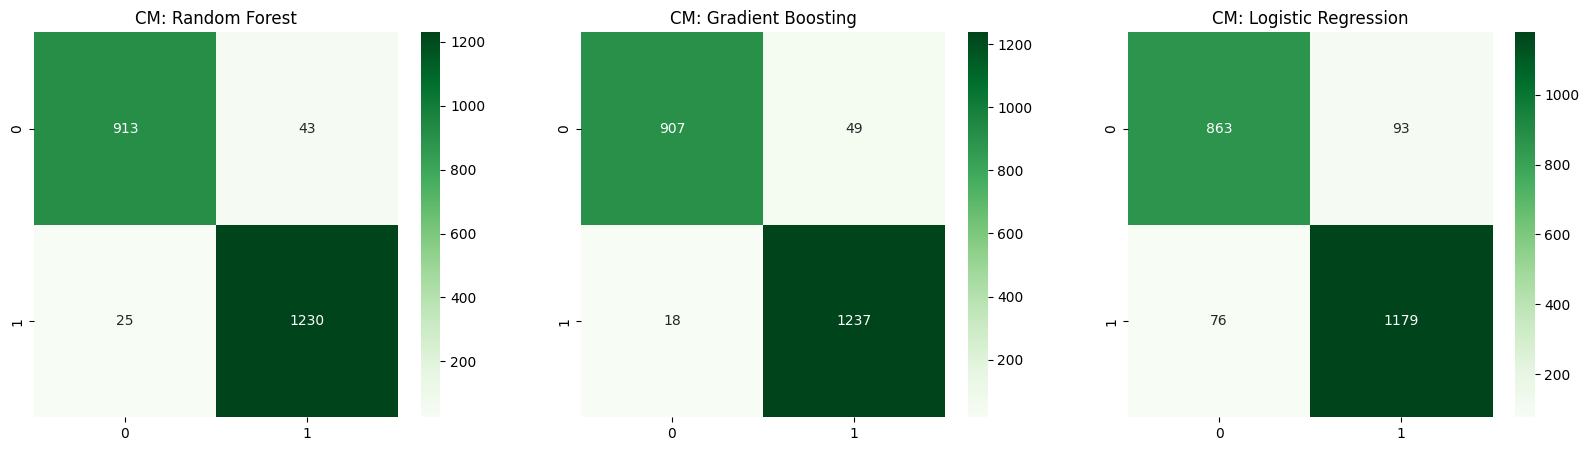

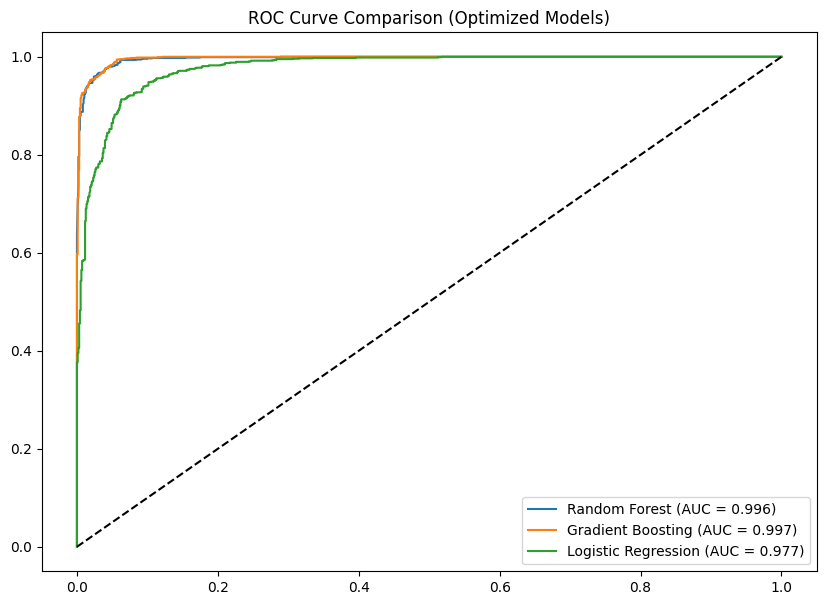


--- FINAL OPTIMIZED COMPARISON TABLE ---
              Model  Accuracy  Precision   Recall      FPR      AUC
  Gradient Boosting  0.969697   0.961897 0.985657 0.051255 0.996604
      Random Forest  0.969245   0.966222 0.980080 0.044979 0.996096
Logistic Regression  0.923564   0.926887 0.939442 0.097280 0.977019


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_curve, auc, precision_score, recall_score, f1_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# Initialize a dictionary to hold the optimized models
optimized_models = {}

# Instantiate models with their best parameters found by Optuna
for name, study in study_results.items():
    best_params = study.best_trial.params
    if name == "Random Forest":
        optimized_models[name] = RandomForestClassifier(**best_params, random_state=42)
    elif name == "Gradient Boosting":
        optimized_models[name] = GradientBoostingClassifier(**best_params, random_state=42)
    elif name == "Logistic Regression":
        # Logistic Regression might require specific solver for C parameter
        if 'solver' in best_params and best_params['solver'] == 'lbfgs':
            optimized_models[name] = LogisticRegression(**best_params, max_iter=2000, random_state=42)
        else:
            optimized_models[name] = LogisticRegression(**best_params, max_iter=2000, random_state=42)


summary_table = []
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
plt.figure(figsize=(10, 7)) # For ROC Curve

for i, (name, model) in enumerate(optimized_models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # 1. Classification Report
    print(f"\nFinal Report: {name}")
    print(classification_report(y_test, y_pred))

    # 2. Confusion Matrix (Plots)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i])
    axes[i].set_title(f'CM: {name}')

    # 3. ROC Curve (Plot)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.3f})')

    # 4. Metric Storage
    tn, fp, fn, tp = cm.ravel()
    summary_table.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "FPR": fp / (fp + tn),
        "AUC": auc(fpr, tpr)
    })

# Finalizing Plots
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison (Optimized Models)')
plt.legend()
plt.show()

# Final Summary Table
print("\n--- FINAL OPTIMIZED COMPARISON TABLE ---")
print(pd.DataFrame(summary_table).sort_values(by='Accuracy', ascending=False).to_string(index=False))

# **Section 5: K-Fold Cross Validation**

--- Running 10-Fold Cross-Validation ---
Random Forest:
  Mean Accuracy: 0.9723
  Std Deviation: 0.0039
Gradient Boosting:
  Mean Accuracy: 0.9745
  Std Deviation: 0.0042
Logistic Regression:
  Mean Accuracy: 0.9277
  Std Deviation: 0.0058


/tmp/ipython-input-4269468541.py:26: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



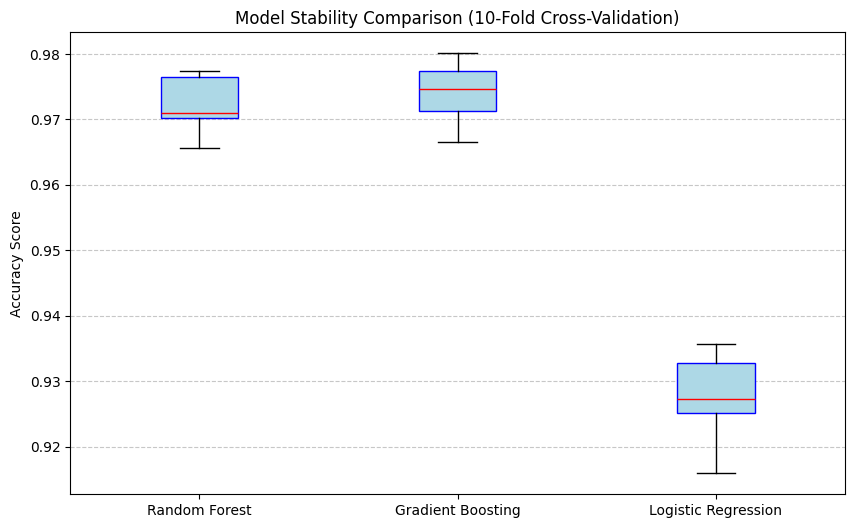

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize K-Fold (10 folds is standard for research)
kf = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = {}

print("--- Running 10-Fold Cross-Validation ---")

for name, model in optimized_models.items():
    # Perform Cross-Validation
    # We use 'accuracy' here, but 'f1' or 'precision' can also be used
    cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy', n_jobs=-1)

    cv_results[name] = cv_scores

    print(f"{name}:")
    print(f"  Mean Accuracy: {np.mean(cv_scores):.4f}")
    print(f"  Std Deviation: {np.std(cv_scores):.4f}")

# 2. Visualize Model Stability with a Boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red'))

plt.title('Model Stability Comparison (10-Fold Cross-Validation)')
plt.ylabel('Accuracy Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- Final Optimized Random Forest Results ---
Test Accuracy: 0.9692

Classification Report:
              precision    recall  f1-score   support

    Phishing       0.97      0.96      0.96       956
  Legitimate       0.97      0.98      0.97      1255

    accuracy                           0.97      2211
   macro avg       0.97      0.97      0.97      2211
weighted avg       0.97      0.97      0.97      2211



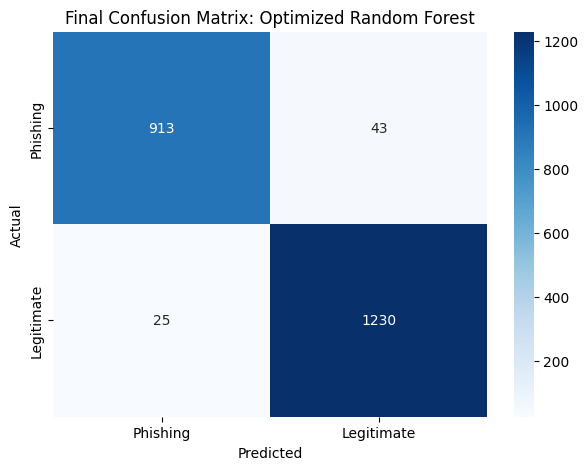

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define the best parameters from Trial 12
best_rf_params = {
    'n_estimators': 129,
    'max_depth': 28,
    'min_samples_split': 2,
    'criterion': 'gini'
}

# 2. Initialize and train the final model
final_rf_model = RandomForestClassifier(**best_rf_params, random_state=42)
final_rf_model.fit(X_train, y_train)

# 3. Evaluate on the test set
y_pred = final_rf_model.predict(X_test)

print("--- Final Optimized Random Forest Results ---")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Phishing', 'Legitimate']))

# 4. Visualize the Confusion Matrix for the Final Model
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Phishing', 'Legitimate'], yticklabels=['Phishing', 'Legitimate'])
plt.title('Final Confusion Matrix: Optimized Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# **Section 6: Visualizing Critical Predictor**

## **Feature Importance**

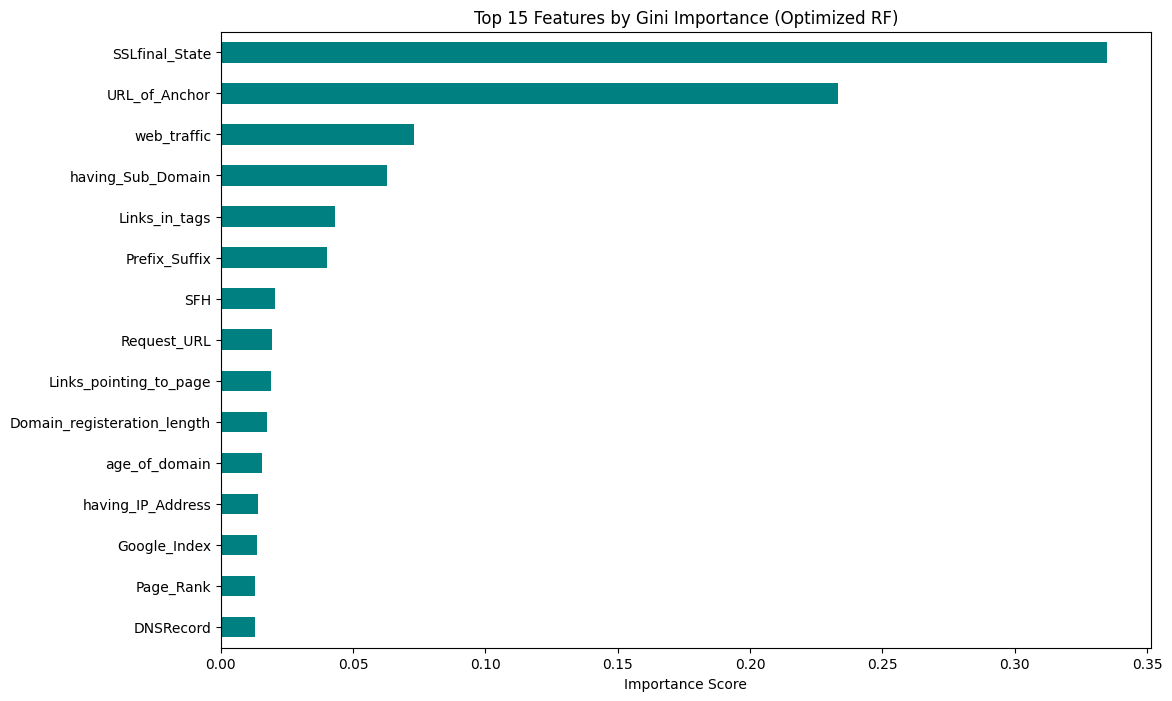

In [ ]:
# 1. Initialize and train with your specific best parameters
best_rf_params = {
    'n_estimators': 129,
    'max_depth': 28,
    'min_samples_split': 2,
    'criterion': 'gini'
}

final_rf = RandomForestClassifier(**best_rf_params, random_state=42)
final_rf.fit(X_train, y_train)

# 2. Extract and Plot Feature Importance
feat_importances = pd.Series(final_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(12, 8))
feat_importances.nlargest(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Features by Gini Importance (Optimized RF)')
plt.xlabel('Importance Score')
plt.show()

## **Shap Plot for Visualization**

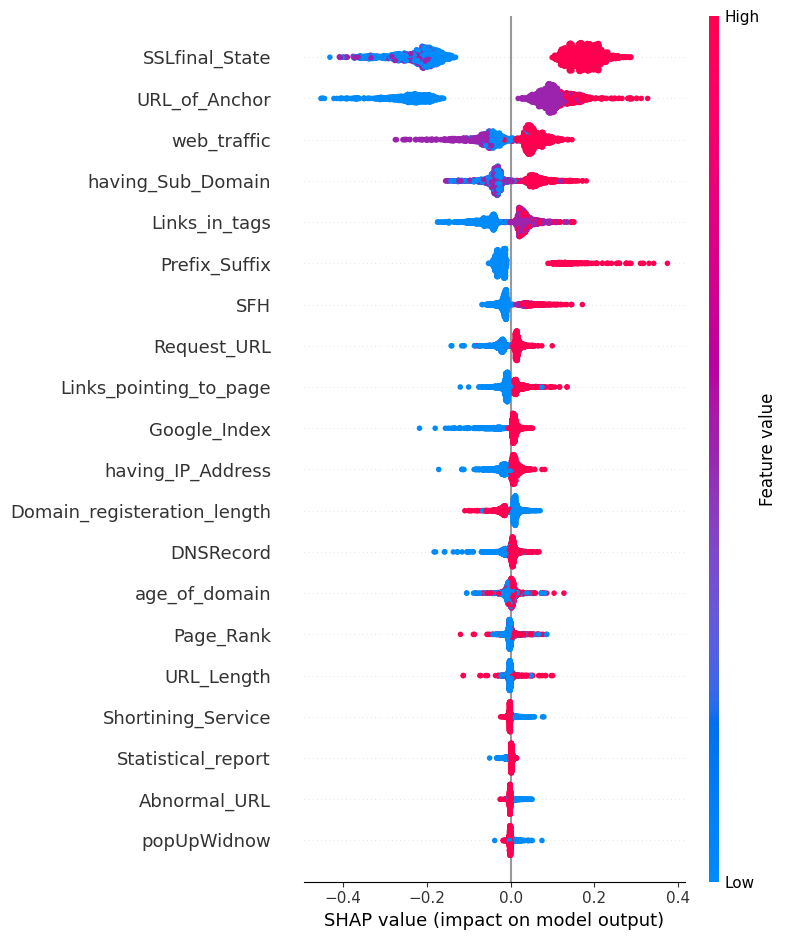

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Create SHAP Explainer
# We use TreeExplainer as it is optimized for Random Forest
explainer = shap.TreeExplainer(final_rf)
shap_values = explainer.shap_values(X_test)

# 2. Summary Plot
# This plot shows the impact of each feature on the model output
plt.figure(figsize=(10, 8))
# Access the SHAP values for the 'Legitimate' class (index 1) across all samples and features
# Assumes shap_values is of shape (num_samples, num_features, num_classes)
shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="dot")
plt.show()

# **Section 7: Impact of Algorithm on False Positive Reduction**

/tmp/ipython-input-1105998675.py:43: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




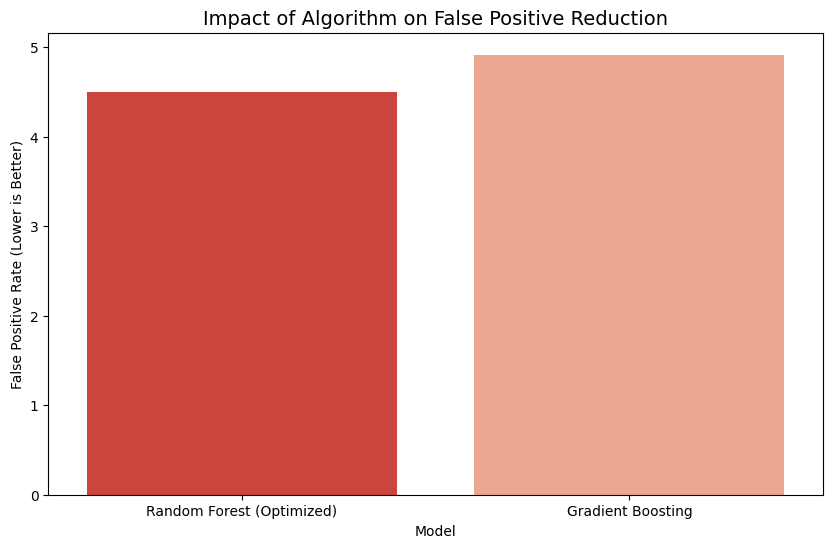

--- Algorithm Comparison Summary ---
                    Model  Accuracy  Precision  False Positive Rate (%)  Legitimate Sites Blocked (FP)
Random Forest (Optimized)  0.969245   0.966222                 4.497908                             43
        Gradient Boosting  0.971054   0.963424                 4.916318                             47


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, confusion_matrix, accuracy_score, classification_report

# 1. Define the Optimized Models
# Using your specific Trial 12 parameters for RF
models = {
    "Random Forest (Optimized)": RandomForestClassifier(
        n_estimators=129, max_depth=28, min_samples_split=2, criterion='gini', random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42
    )
}

comparison_data = []

# 2. Training and Metric Extraction
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate False Positive Rate (FPR)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr = (fp / (fp + tn)) * 100  # Percentage

    comparison_data.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "False Positive Rate (%)": fpr,
        "Legitimate Sites Blocked (FP)": fp
    })

# 3. Create Comparison Table
comparison_df = pd.DataFrame(comparison_data)

# 4. Visualize the Reduction of False Positives
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='False Positive Rate (%)', data=comparison_df, palette='Reds_r')
plt.title('Impact of Algorithm on False Positive Reduction', fontsize=14)
plt.ylabel('False Positive Rate (Lower is Better)')
plt.show()

print("--- Algorithm Comparison Summary ---")
print(comparison_df.to_string(index=False))